In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# labeled Supervised Learning : Classification & Regression

지도학습에는 분류와 회귀가 있다

# *** Classification Algorithms ***

## ** KNN (K Nearest Neighbor) **

새로운 데이터가 들어왔을때, 어떤 그룹에 속하는지 분류. 가장 근처에 있는 k개의 데이터를 따라감(유사도). 결측치(NaN) 추정에 사용. Euclidean Distance, Manhattan Distance 등

K가 작을수록 Overfitting

## 두 그룹으로 분류하는 Binary KNN

In [131]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 데이터 읽어오기

In [132]:
# getting data
citrus = pd.read_csv("https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/citrus.csv")
print(citrus.shape)
citrus.head()


(10000, 6)


,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [133]:
print(citrus.info())
print(citrus.describe())
print('\n\n', citrus['name'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB
None
           diameter        weight           red         green          blue
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean       9.975685    175.050792    153.847800     76.010600     11.363200
std        1.947844     29.212119     10.432954     11.708433      9.061275
min        2.960000     86.760000    115.000000     31.000000      2.000000
25%        8.460000    152.220000    147.000000     68.000000      2.000000
50%        9.980000    174.985000    154.000000     76.0

<Axes: xlabel='diameter', ylabel='Count'>

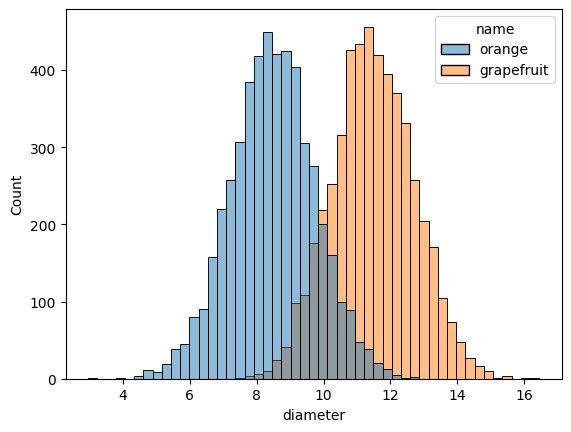

In [134]:
sns.histplot(x='diameter', data = citrus, hue = 'name')

이상치 확인

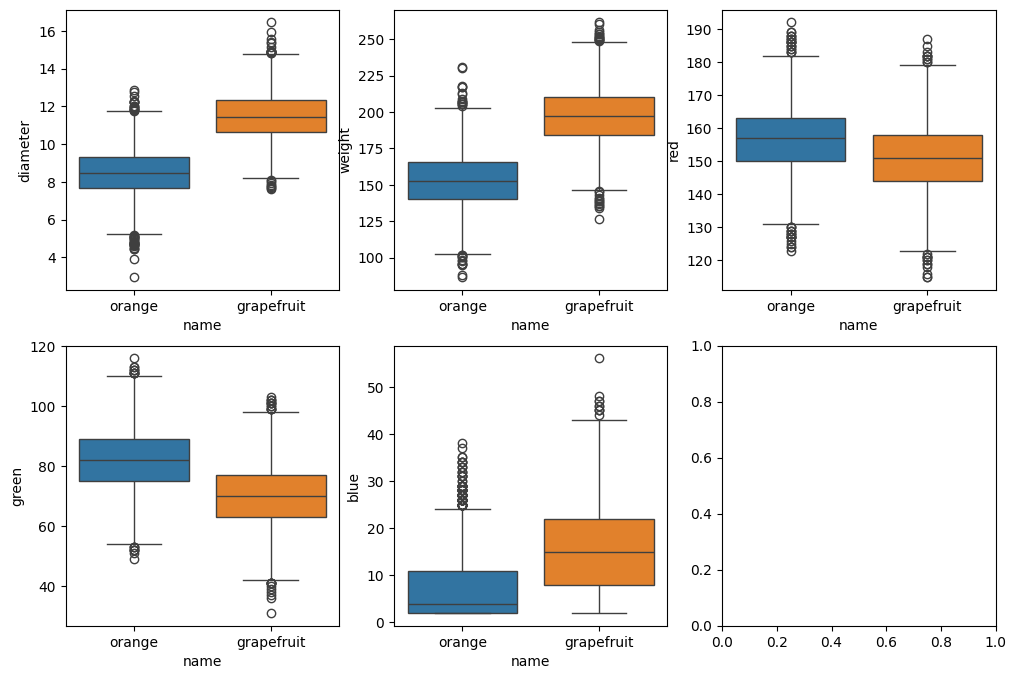

In [135]:
numeric_cols = citrus[['diameter', 'weight', 'red', 'green', 'blue']]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x="name", y=col, data=citrus, hue="name", ax=axes[i])

plt.show()

In [136]:
outliers = {}
for col in numeric_cols:
  Q1 = citrus[col].quantile(0.25)    # 25%
  Q3 = citrus[col].quantile(0.75)    # 75%

  IQR = Q3 - Q1   # 박스의 높이

  lower_bound = Q1 - IQR*1.5
  upper_bound = Q3 + IQR*1.5

  outlier = citrus.loc[ (citrus[col] < lower_bound) | (citrus[col] > upper_bound), : ]

  outliers[col] = outlier

결측치 확인

In [137]:
citrus.isna().sum()

,0
name,0
diameter,0
weight,0
red,0
green,0
blue,0


## * Train, Validation, Test 데이터 분리 *

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
train, test = train_test_split(citrus, test_size=0.2, random_state=SEED)    # train 8, test 2

In [140]:
# 종속변수x와 독립변수y(name)으로 나누기
x_train = train.drop('name', axis=1)
y_train = train['name']

In [141]:
x_train, x_validation, y_train, y_validation = train_test_split(
          x, y, test_size=0.25, random_state=SEED
          )     # train 6, validation 2

## * 데이터 전처리 *

### Encoding

x는 문자데이터가 없으므로, 아무것도 숫자로 바꿀 필요 없음 (Encoding 필요없음)
y는 과일 이름(문자)이니까 숫자로 바꾸는 Encoding 필요

In [142]:
label_dict = {'grapefruit' : 0, 'orange' : 1}
y_train_e = y_train.map(label_dict)
y_validation_e = y_validation.map(label_dict)

하지만 숫자가 들쑥날쑥하므로 x의 scaling 필요

### Min Max Scaling

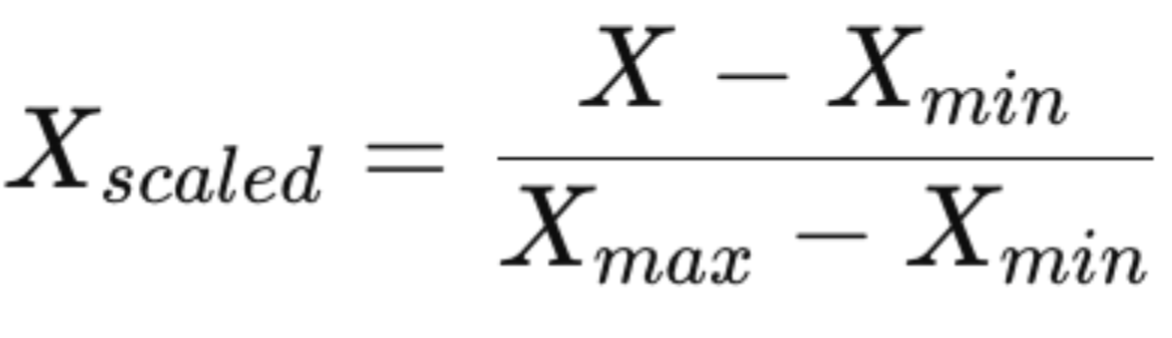

In [143]:
x_train_minmax_s = (x_train - x_train.min()) / (x_train.max() - x_train.min())
x_validation_minmax_s = (x_validation - x_validation.min()) / (x_validation.max() - x_validation.min())

### Standard Scaler
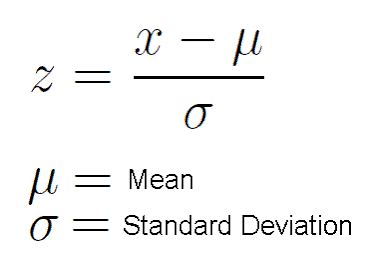

In [144]:
x_train_standard_s = (x_train - x_train.mean()) / x_train.std()
x_validation_standard_s = (x_validation - x_validation.mean()) / x_validation.std()

또는

In [145]:
from sklearn.preprocessing import StandardScaler

최종 데이터

In [146]:
x_train_minmax_s = x_train_minmax_s.to_numpy()
x_train_standard_s = x_train_standard_s.to_numpy()
x_validation_minmax_s = x_validation_minmax_s.to_numpy()
x_validation_standard_s = x_validation_standard_s.to_numpy()

y_train = y_train_e.to_numpy()
y_validation = y_validation_e.to_numpy()

In [147]:
x_train_minmax_s.shape, x_train_standard_s.shape, x_validation_minmax_s.shape, x_validation_standard_s.shape, y_train.shape, y_validation.shape

((6000, 5), (6000, 5), (2000, 5), (2000, 5), (6000,), (2000,))

## * 모델 학습 *

In [148]:
from sklearn.neighbors import KNeighborsClassifier

In [149]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(x_train_minmax_s, y_train_e)    # standard scaling 써도 됨

KNeighborsClassifier()

## * 학습 결과 확인 *

In [150]:
y_predict = clf.predict(x_validation_minmax_s)
print(y_predict[:20])   # 학습된 기계가 예측한 값
print(y_validation[:20])    # 실제 정답

print ((y_validation == y_predict).sum() / len(y_validation)  )   # 정확도

[1 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0]
[1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0]
0.9205


### confusion matrix 함수 만들기

In [151]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 0.9205
2. Recall: 0.8951
3. Precision: 0.9432
4. F1 Score: 0.9185


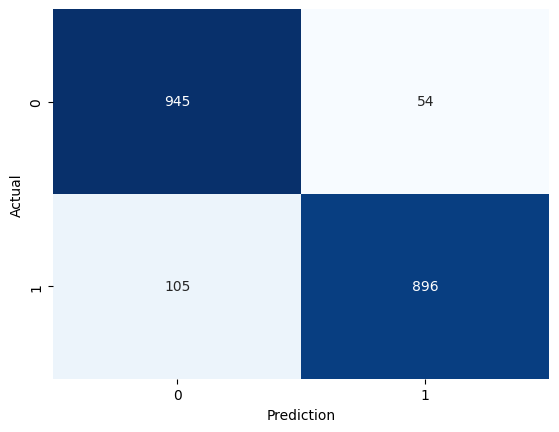

In [152]:
print_metrics(y_validation, y_predict)

## Model Tuning

k 를 바꿔가며 시행 or scaling 방법 바꾸기

## * Cross Validation *
교차검증 : train과 validation 세트를 섞어서 다시 나누기

### cross_val_score 사용

In [153]:
from sklearn.model_selection import cross_val_score

In [154]:
x_train = train.drop('name', axis=1)
y_train = train['name']

scaler = StandardScaler()
scaler.fit(x_train)
x_train_standard_automatic = scaler.transform(x_train)      # scaling은 그냥 다르게 해봄

y_train_e = y_train.map(label_dict)
y_train_e = y_train_e.to_numpy()

In [155]:
clf = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(
    clf, x_train_standard_automatic, y_train_e, cv=5, scoring='accuracy'
            )
scores    # 이 5개를 평균낸 게 점수

array([0.92125 , 0.91625 , 0.916875, 0.920625, 0.920625])

### GridSearchCv 사용

In [156]:
from sklearn.model_selection import GridSearchCV

In [157]:
clf = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9,11],
              'weights' : ['uniform', 'distance'],
              'p' : [1,2]
              }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)


grid_search.fit(x_train_standard_automatic, y_train_e)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

우리가 찾는 모델 = grid_search.best_estimator

In [158]:
best_model = grid_search.best_estimator_
best_model

KNeighborsClassifier(n_neighbors=11)

## * Test *

항상 절차는
1. x, y 분리
2. x scaling, y encoding    - 이때 scaling 방식 통일하기
3. 테스트

In [168]:
x_test = test.drop('name', axis=1)
y_test = test['name']

In [169]:
x_test_scaled = scaler.transform(x_test)
y_test_e = y_test.map(label_dict)
y_test_e = y_test_e.to_numpy()

1. Accuracy: 0.9260
2. Recall: 0.9209
3. Precision: 0.9320
4. F1 Score: 0.9264


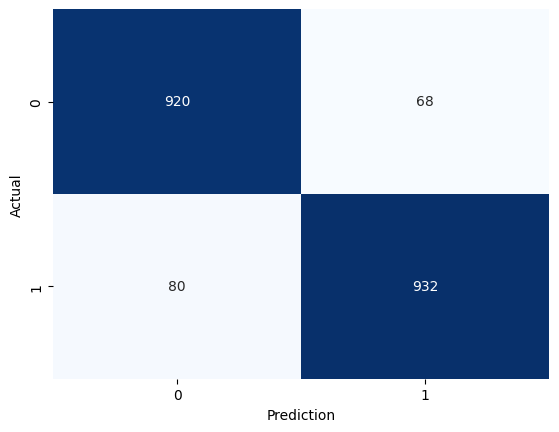

In [170]:
y_predict = best_model.predict(x_test_scaled)

print_metrics(y_test_e, y_predict)

## 모델 저장

In [171]:
save_data = {'scaler' : scaler, 'label_dict' : label_dict, 'best_model' : best_model}

import joblib
joblib.dump(save_data, '6_24_KNN.joblib')


['6_24_KNN.joblib']